# Group 69 — actual local replication artifact verification

Executed on 30 September 2026. This notebook reads and verifies artifacts produced by the completed
three-seed training run; it does **not** claim that the training was executed in these cells. The
training implementation is in `src/` and `tools/reproduce_main.py`, its predeclared configuration,
logs, checkpoints and predictions are in `experiments/completed/outputs_replication_efficient/`. B0/B1 local evidence is
in `experiments/completed/outputs_replication_baselines/`. Run from the repository directory with supplied data at `../../PIQA`.

This is separate from the original A100 study in `CITS4012_69.ipynb`. It provides genuine executed
metric-recomputation, paired-comparison, error-analysis and figure outputs for the local replication.
The complete revised baseline/ablation notebook still needs a full fresh Colab execution before promotion.


In [1]:
from pathlib import Path
import json
root = Path.cwd()
print("SAVED PRE-TRAINING PROTOCOL")
print((root/'experiments/completed/outputs_replication_efficient/protocol.json').read_text(encoding='utf8'))
for path in sorted((root/'experiments/completed/outputs_replication_efficient/logs').glob('*.jsonl')):
    print("SAVED TRAINING LOG:", path.name)
    print(path.read_text(encoding='utf8'))


SAVED PRE-TRAINING PROTOCOL
{
  "purpose": "fixed configuration replication; no tuning; historical split retained",
  "seeds": [
    42,
    43,
    44
  ],
  "config": {
    "drive_zip": "/content/drive/MyDrive/Group69/PIQA.zip",
    "local_zip_glob": "*.zip",
    "data_dir": "../../PIQA",
    "out_dir": "outputs_replication_efficient",
    "seed": 42,
    "val_frac": 0.1,
    "vocab_size": 8000,
    "min_frequency": 2,
    "max_goal_len": 40,
    "max_sol_len": 96,
    "d_model": 256,
    "n_heads": 4,
    "n_layers": 4,
    "d_ff": 1024,
    "dropout": 0.2,
    "attn_dropout": 0.1,
    "max_len": 160,
    "use_diff_tags": true,
    "use_cross_solution": true,
    "pool_mode": "diff_attn",
    "objective": "pairwise",
    "mlm_epochs": 10,
    "batch_size": 128,
    "lr": 0.0003,
    "weight_decay": 0.05,
    "epochs": 20,
    "warmup_ratio": 0.06,
    "label_smoothing": 0.1,
    "patience": 6,
    "grad_clip": 1.0,
    "mlm_lr": 0.0005,
    "mlm_prob": 0.15,
    "amp": true,
    "nu

In [2]:
"""Recompute local replication evidence; descriptive, post-training analysis only."""
import csv
import hashlib
import json
import sys
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from tokenizers import Tokenizer

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'tools'))
from project_paths import resolve_artifact
from evaluate import bootstrap_ci, holm_adjust, mcnemar_exact
from config import Config
from data import load_piqa


def read(path):
    return json.loads(path.read_text(encoding='utf8'))


def rows(path):
    return [json.loads(line) for line in path.read_text(encoding='utf8').splitlines()]


def write_csv(path, records):
    with path.open('w', encoding='utf8', newline='') as stream:
        writer = csv.DictWriter(stream, fieldnames=list(records[0]))
        writer.writeheader()
        writer.writerows(records)


def main():
    out = ROOT / 'report_support'
    run = ROOT / 'experiments/completed/outputs_replication_efficient'
    base = ROOT / 'experiments/completed/outputs_replication_baselines'
    result = read(run / 'results/dact_replication_test.json')
    baseline = read(base / 'results.json')
    _, raw_val, raw_test = load_piqa(Config(data_dir=str(ROOT / '../../PIQA')))
    records, checks, test_rows = [], [], {}
    for split, n in [('val', 1612), ('test', 1838)]:
        reference = None
        raw = raw_val if split == 'val' else raw_test
        for name in ['seed42', 'seed43', 'seed44', 'B0', 'B1']:
            path = (base / 'predictions' / f'{name}_{split}.jsonl' if name.startswith('B')
                    else run / 'predictions' / f'dact_replication_{name}_{split}.jsonl')
            data = rows(path)
            assert len(data) == n
            identity = [(x['index'], x['goal'], x['candidate_1'], x['candidate_2'], x['gold_label']) for x in data]
            if reference is None:
                reference = identity
                assert identity == [(i, x['goal'], x['sol1'], x['sol2'], x['label']) for i, x in enumerate(raw)]
            assert identity == reference
            assert [x['index'] for x in data] == list(range(n))
            for x in data:
                assert x['correct'] == (x['predicted_label'] == x['gold_label'])
                if 'probability_candidate_2' in x:
                    p = x['probability_candidate_2']
                    assert 0 <= p <= 1 and np.isclose(p + x['probability_candidate_1'], 1)
                    assert x['predicted_label'] == int(p > .5)
            acc = np.mean([x['correct'] for x in data])
            expected = (baseline[name][f'{split}_accuracy'] if name.startswith('B') else
                        result[split]['runs'][int(name[-2:]) - 42])
            assert np.isclose(acc, expected, atol=1e-12)
            records.append({'model': name, 'split': split, 'n': n, 'correct': sum(x['correct'] for x in data),
                            'accuracy': float(acc), 'source': str(path.relative_to(ROOT))})
            checks.append(str(path.relative_to(ROOT)))
            if split == 'test':
                test_rows[name] = data
    for split in ('val', 'test'):
        assert np.isclose(np.mean(result[split]['runs']), result[split]['mean'])
        assert np.isclose(np.std(result[split]['runs'], ddof=1), result[split]['std'])
    for seed_run in result['runs']:
        log = rows(run / 'logs' / f"dact_replication_seed{seed_run['seed']}.jsonl")
        epochs = [x for x in log if x['event'] == 'epoch']
        assert len(epochs) == seed_run['epochs']
        assert max(x['val_acc'] for x in epochs) == seed_run['val_acc']
        assert resolve_artifact(seed_run['ckpt']).exists()
        assert resolve_artifact(seed_run['ckpt'] + '.json').exists()
    best = max(result['runs'], key=lambda x: x['val_acc'])['seed']
    assert best == result['test']['best_val_seed']
    representative = test_rows[f'seed{best}']
    gold = np.array([x['gold_label'] for x in representative])
    pred = np.array([x['predicted_label'] for x in representative])
    assert np.allclose(bootstrap_ci(pred, gold), result['test']['ci95'])
    pairs = []
    # Exploratory family specified here: representative DACT vs local B0 and B1.
    # Same-item resampling preserves pairing; seed chosen only by validation.
    rng = np.random.default_rng(20260930)
    samples = rng.integers(0, len(gold), size=(10000, len(gold)))
    for name in ('B0', 'B1'):
        bpred = np.array([x['predicted_label'] for x in test_rows[name]])
        b, c, p = mcnemar_exact(pred, bpred, gold)
        difference = (pred == gold).astype(float) - (bpred == gold).astype(float)
        interval = np.quantile(difference[samples].mean(1), [.025, .975])
        pairs.append({'comparison': f'DACT seed {best} minus {name}', 'accuracy_difference_pp': difference.mean()*100,
                      'paired_bootstrap_low_pp': interval[0]*100, 'paired_bootstrap_high_pp': interval[1]*100,
                      'DACT_only_correct': b, 'baseline_only_correct': c, 'exact_McNemar_p': p})
    for record, adjusted in zip(pairs, holm_adjust([p['exact_McNemar_p'] for p in pairs])):
        record['Holm_p_two_comparisons'] = float(adjusted)
    tok = Tokenizer.from_file(str(run / 'tokenizer.json'))
    features = []
    for x in representative:
        ids = [tok.encode(x[f'candidate_{k}']).ids for k in (1, 2)]
        p = x['probability_candidate_2']
        features.append({**x, 'max_candidate_tokens': max(map(len, ids)),
                         'truncated': any(len(i) > 96 for i in ids),
                         'identical_truncated_tokens': ids[0][:96] == ids[1][:96],
                         'confidence': max(p, 1-p)})
    strata = []
    groups = {'all': features, 'truncated': [x for x in features if x['truncated']],
              'not truncated': [x for x in features if not x['truncated']],
              'identical retained option tokens': [x for x in features if x['identical_truncated_tokens']],
              'confidence >= .8': [x for x in features if x['confidence'] >= .8]}
    for label, group in groups.items():
        strata.append({'group': label, 'n': len(group), 'correct': sum(x['correct'] for x in group),
                       'accuracy': float(np.mean([x['correct'] for x in group])) if group else None})
    errors = [x for x in features if not x['correct']]
    sampled = sorted(np.random.default_rng(20260930).choice(len(errors), 12, replace=False))
    sample = [errors[i] for i in sampled]
    attention = []
    for path in sorted((run / 'figures').glob('*.png.json')):
        info = read(path)
        index = int(path.name.split('.')[0].split('_')[-1])
        item = representative[index]
        assert info['goal'] == item['goal'] and info['label'] == item['gold_label']
        assert info['pred'] == item['predicted_label']
        assert all(info[f'candidate_{k}'] == item[f'candidate_{k}'] for k in (1, 2))
        top = []
        for option in info['options']:
            weights = np.array(option['pool'])
            assert np.isclose(weights.sum(), 1, atol=1e-5)
            positions = option['sol_pos']
            top.append([{'token': option['tokens'][positions[j]], 'weight': float(weights[j]),
                         'difference_tag': option['diff'][j]} for j in np.argsort(-weights)[:5]])
        attention.append({'index': index, 'correct': item['correct'], 'top_pool_tokens_by_option': top,
                          'probability_delta_fp32_vs_saved_amp': abs(info['probs'][1]-item['probability_candidate_2'])})
    write_csv(out / 'replication_results.csv', records)
    write_csv(out / 'replication_comparisons.csv', pairs)
    write_csv(out / 'replication_error_strata.csv', strata)
    (out / 'replication_error_sample.json').write_text(json.dumps(sample, indent=2, ensure_ascii=False), encoding='utf8')
    (out / 'replication_attention_summary.json').write_text(json.dumps(attention, indent=2), encoding='utf8')
    manifest = {str(p.relative_to(ROOT)): hashlib.sha256(p.read_bytes()).hexdigest()
                for directory in (run, base) for p in sorted(directory.rglob('*')) if p.is_file()}
    (out / 'replication_manifest.json').write_text(json.dumps(manifest, indent=2), encoding='utf8')
    summary = {'prediction_files_verified': checks, 'prediction_rows_verified': sum(x['n'] for x in records),
               'prediction_text_labels_match_supplied_data': True,
               'metrics_match': True, 'seed_aggregate_matches': True, 'validation_checkpoint_selection_matches': True,
               'representative_seed': best, 'bootstrap_CI_matches': True, 'attention_metadata_matches': True,
               'comparisons': pairs, 'error_strata': strata,
               'note': 'Exploratory post-run comparisons; local environment; no model selection from test.'}
    (out / 'replication_checks.json').write_text(json.dumps(summary, indent=2), encoding='utf8')
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
    for seed in (42, 43, 44):
        ep = [x for x in rows(run/'logs'/f'dact_replication_seed{seed}.jsonl') if x['event']=='epoch']
        for ax, key in zip(axes, ('train_loss', 'val_loss', 'val_acc')):
            ax.plot([x['epoch'] for x in ep], [x[key] for x in ep], marker='.', label=f'seed {seed}')
            ax.set(xlabel='QA epoch', ylabel=key.replace('_', ' ')); ax.grid(alpha=.2)
    axes[-1].legend(); fig.suptitle('Local fixed-recipe replication (separate from historical A100 study)')
    fig.tight_layout(); fig.savefig(out/'figures/replication_training_curves.png', dpi=300); plt.close(fig)
    print(json.dumps(summary, indent=2))
    print('ERROR SAMPLE:', json.dumps(sample, ensure_ascii=False, indent=2))


if __name__ == '__main__':
    main()


{
  "prediction_files_verified": [
    "experiments\\completed\\outputs_replication_efficient\\predictions\\dact_replication_seed42_val.jsonl",
    "experiments\\completed\\outputs_replication_efficient\\predictions\\dact_replication_seed43_val.jsonl",
    "experiments\\completed\\outputs_replication_efficient\\predictions\\dact_replication_seed44_val.jsonl",
    "experiments\\completed\\outputs_replication_baselines\\predictions\\B0_val.jsonl",
    "experiments\\completed\\outputs_replication_baselines\\predictions\\B1_val.jsonl",
    "experiments\\completed\\outputs_replication_efficient\\predictions\\dact_replication_seed42_test.jsonl",
    "experiments\\completed\\outputs_replication_efficient\\predictions\\dact_replication_seed43_test.jsonl",
    "experiments\\completed\\outputs_replication_efficient\\predictions\\dact_replication_seed44_test.jsonl",
    "experiments\\completed\\outputs_replication_baselines\\predictions\\B0_test.jsonl",
    "experiments\\completed\\outputs_replic

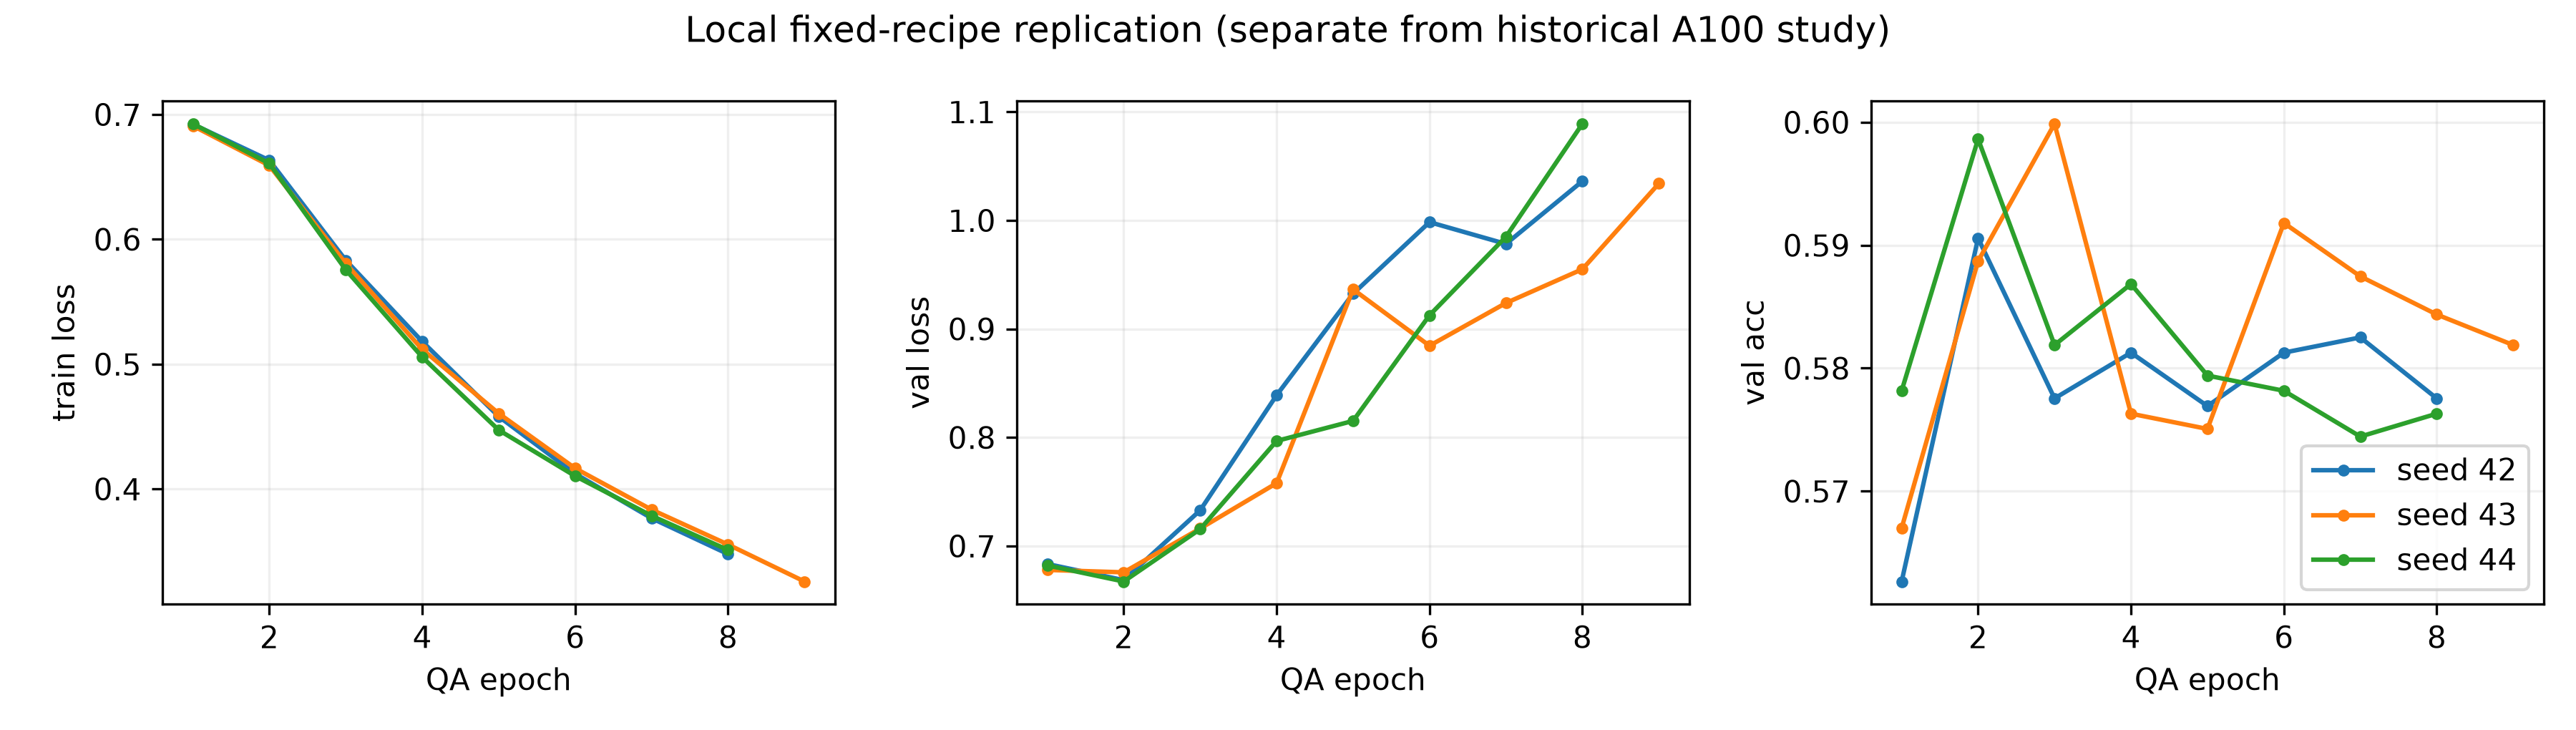

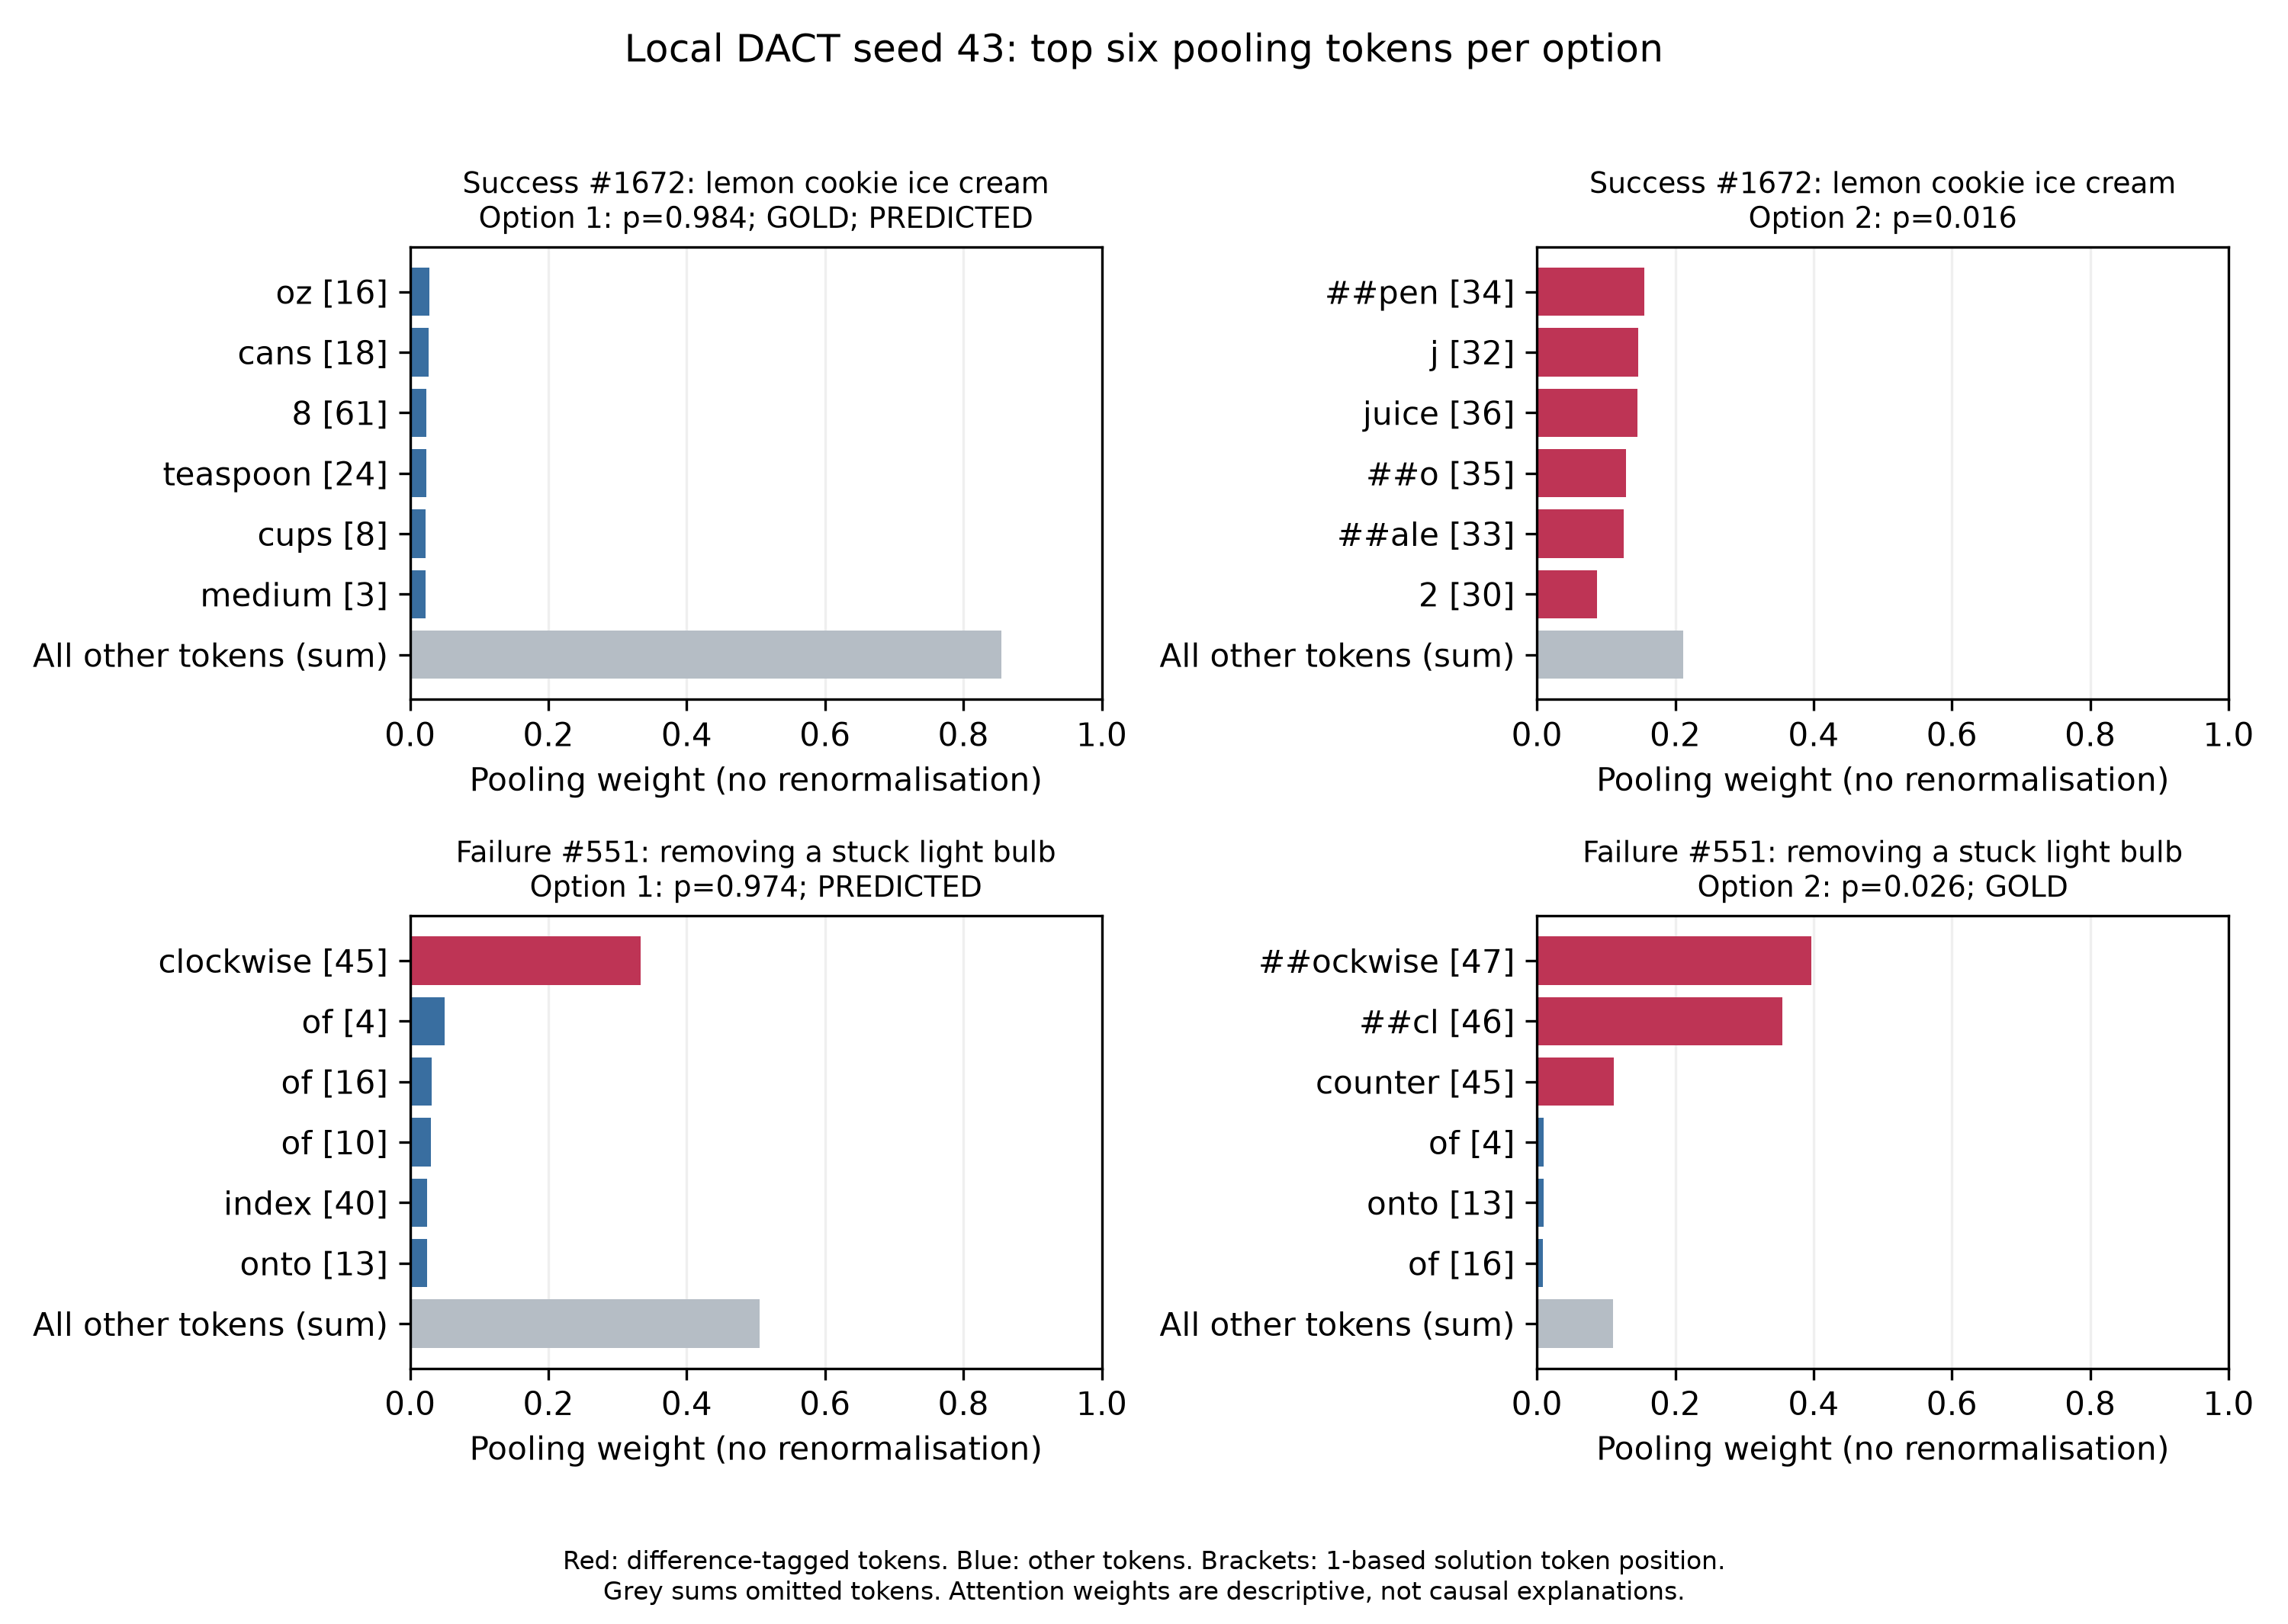

In [3]:
from IPython.display import Image, display
for name in ('replication_training_curves.png', 'replication_attention_compact.png'):
    display(Image(filename=str(ROOT/'report_support/figures'/name)))


# Independent local replication — completed 30 September 2026

These results come from `experiments/completed/outputs_replication_efficient/`, not the original A100 comparison.
The fixed recipe, seeds and evaluation rule were written to `protocol.json` before training.
No new hyperparameter or architecture selection used test data. Hardware, library versions, precision,
loader workers and selected-position MLM projection differ; improved accuracy cannot be attributed
to any one of those changes. Main architecture, mathematical objective and historical preprocessing
remain the same. All ten MLM epochs and three QA runs completed; checkpoints and item predictions exist.

| Model | Validation accuracy (%) | Test accuracy (%) |
|---|---:|---:|
| DACT seed 42 | 59.0571 | 62.2960 |
| DACT seed 43 | 59.9876 | 62.5680 |
| DACT seed 44 | 59.8635 | 62.8400 |
| DACT mean ± sample SD | 59.6361 ± 0.5052 | 62.5680 ± 0.2720 |
| B0 majority | 50.0000 | 50.4897 |
| B1 TF-IDF + LR, C=3 | 58.9950 | 60.8814 |

Seed 43 was selected by validation. Its accuracy is 1,150/1,838 and its item-bootstrap 95% CI is
[60.3917, 64.6368]%. This CI does not incorporate seed selection/training variance. Excluding the
known training/test duplicate gives 62.5476% on 1,837 examples, a sensitivity analysis only.

`tools/analyse_replication.py` checks ten prediction files (17,250 rows), supplied text/labels,
probability/decision consistency, all accuracies, seed statistics, validation maxima, checkpoint
existence and figure metadata. `replication_manifest.json` hashes the complete local evidence.

## Exploratory paired comparisons

Same-item bootstrap resampling uses 10,000 replicates, seed 20260930. McNemar tests compare correctness
on identical items. The post-run family consists of representative DACT versus B0 and B1; Holm corrects
these two tests. These are exploratory, not preregistered confirmatory claims.

| Comparison | Difference (percentage points) | Paired bootstrap 95% CI | DACT-only / baseline-only correct | Exact p | Holm p |
|---|---:|---|---:|---:|---:|
| DACT − B0 | +12.0783 | [8.8683, 15.1795] | 564 / 342 | 1.60e-13 | 3.20e-13 |
| DACT − B1 | +1.6866 | [-0.7617, 4.0805] | 277 / 246 | .18953 | .18953 |

DACT clearly exceeds this majority reference in the local run. Evidence for an advantage over lexical
LR remains uncertain; failure to reject equality is not evidence of equivalence. Do not compare this
new DACT score to old ablations as if only their architectural component differed.

## Training and structural error analysis

`figures/replication_training_curves.png` shows falling training loss but rising validation loss after
the first few epochs. Best validation checkpoints occur at QA epochs 2, 3 and 2 for seeds 42, 43 and 44.
The later high-confidence errors are consistent with overfitting; this does not identify their cause.

| Seed-43 subgroup | Correct / n | Accuracy (%) |
|---|---:|---:|
| All supplied test items | 1,150 / 1,838 | 62.57 |
| Either solution truncated | 24 / 32 | 75.00 |
| Neither solution truncated | 1,126 / 1,806 | 62.35 |
| Identical retained option tokens | 0 / 2 | 0.00 |
| Predicted confidence at least .8 | 308 / 420 | 73.33 |

Truncation demonstrably makes two distinctions unavailable, but the aggregate table does not show
that truncated items are generally harder. Subgroups are small, overlap and were analysed after training.
Of the 420 high-confidence predictions, 112 are wrong: confidence is not a guarantee of correctness.

## Random sample of actual errors

Twelve of the 688 seed-43 errors were sampled without replacement using NumPy RNG seed 20260930,
before assigning the following qualitative categories. Full inputs and probabilities are in
`replication_error_sample.json`. One reviewer assigned one primary category per example after reading
it. Categories overlap conceptually; these counts describe this small exploratory sample only.
Gold labels are dataset annotations, not independent verification of every real-world assertion.

| Test index | Gold → predicted option | Category | Observed contrast / limitation |
|---:|---|---|---|
| 307 | 1 → 2 | Material/causal knowledge | Dechlorinated versus chlorinated aquarium-filter rinse; full 96-token input retained. |
| 588 | 2 → 1 | Spatial/temporal relation | Adhesive over versus under protective painter's tape. |
| 648 | 1 → 2 | Object/tool affordance | Peanut butter versus a cat as mouse-trap bait. |
| 702 | 2 → 1 | Ingredient/lexical compatibility | Blood-orange juice versus pigs' blood in fudge; 117-token option is truncated, but the retained options still differ. |
| 713 | 2 → 1 | Material/causal knowledge | Penny versus button in a flower vase; the dataset's claimed benefit was not independently validated. |
| 735 | 1 → 2 | Material/causal knowledge | Coolest versus hottest gas-purchase timing; the distractor also contradicts its own cooler-temperature explanation. |
| 779 | 2 → 1 | Material/causal knowledge | Biaxial versus woven fiberglass; domain-specific property distinction, not independently validated. |
| 861 | 2 → 1 | Object/tool affordance | Hot-glue gun versus sanding belt for attaching cardboard. |
| 880 | 1 → 2 | Object/tool affordance | Colander versus pot for rinsing and shaking pumpkin seeds dry. |
| 1050 | 1 → 2 | Object/tool affordance | Masking tape versus magnets on either side of an unspecified table. |
| 1360 | 1 → 2 | Underspecified equipment | Oven versus Dutch oven for macaroni and cheese; the wording does not fully establish equipment constraints. |
| 1421 | 1 → 2 | Spatial/temporal relation | Hairspray after versus before inflating a balloon; label-level contrast only. |

Sample category counts: material/causal knowledge 4, object/tool affordance 4, spatial/temporal relation 2,
ingredient/lexical compatibility 1, underspecified equipment 1. They are not an estimate of category
prevalence across PIQA, and no architecture change was selected from these test examples.

## Measured attention: success and failure

Four cases were chosen by the pre-existing deterministic rule: two most-confident correct and two
most-confident wrong predictions. Full head-averaged attention PNGs and numeric JSON sidecars are in
the run's `figures/` directory. All were inspected. For the six-page report, prefer the compact SVG/PNG
in `report_support/figures/replication_attention_compact.*`; long full heatmaps need zooming and should
not be squeezed into an ACL column. The compact plot displays six largest pooling weights plus the
sum of all omitted weights, without renormalisation or changed model inference.

- **Success #1672, p(gold option 1)=.984:** the ice-cream distractor adds jalapeño juice. The added
  subwords and `juice` dominate option 2's pooling; option 1 has no insertion tokens and distributes
  weight across its recipe. This pattern is compatible with detecting a local contrast, but does not
  prove the model knows food preparation or that these weights caused the correct decision.
- **Success #130, p(gold option 2)=.979:** brown-butter basting beats the rice-ball alternative. The
  largest gold-option pooling weight is on `##ty` in “nutty” (.228), followed by “meat” (.124).
  Subword fragmentation makes word-level interpretations approximate.
- **Failure #551, p(wrong option 1)=.974:** the bulb-removal options differ in rotation direction.
  Pooling puts .333 on “clockwise” and .861 in total on the three “counterclockwise” subwords, yet
  selects the dataset's wrong direction. Attending to the distinction is insufficient to resolve it.
- **Failure #1244, p(wrong option 1)=.974:** a weight-loss item contrasts protein substitution with
  carbohydrate removal. The prediction disagrees with the dataset label; this underspecified health
  question is weak evidence of physical-reasoning ability and is not treated as dietary advice or an
  independently established factual error. It remains disclosed because the selection rule chose it.

The last-layer goal-attention panels sometimes concentrate on punctuation/function words, and the
cross-option matrices often have vertical bands rather than interpretable one-to-one matching.
All maps are descriptive. Slices omit other keys/CLS sink and need not sum to one. The +1 initial
difference bias remains a confound in explaining concentration. Figure inference uses fp32 while
saved batch evaluation used AMP; maximum probability discrepancy across these four cases is .000117,
with identical predicted labels. The untouched batch predictions define reported accuracy.
